# SF Graph

SF graph: 12 nodes, 132 edges
pi_bar (crime rate): [0.1536 0.1039 0.1028 0.1005 0.0958 0.0958 0.0855 0.0739 0.0554 0.0497
 0.0439 0.0393]


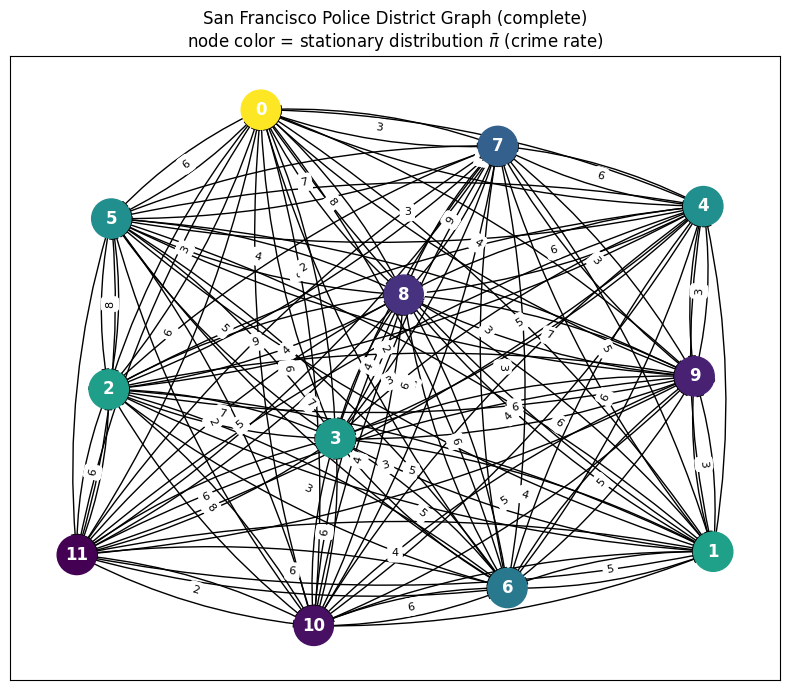

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from graph import san_francisco_graph

A_sf, W_sf, pi_bar_sf = san_francisco_graph()

print(f"SF graph: {A_sf.shape[0]} nodes, {int(A_sf.sum()) - A_sf.shape[0]} edges")
print("pi_bar (crime rate):", np.round(pi_bar_sf, 4))

G_sf = nx.from_numpy_array(A_sf * W_sf, create_using=nx.DiGraph)
G_sf.remove_edges_from(nx.selfloop_edges(G_sf))

pos = nx.spring_layout(G_sf, seed=42)
edge_labels = {(i, j): int(w) for i, j, w in G_sf.edges(data="weight")}

plt.figure(figsize=(8, 7))
nx.draw_networkx_nodes(G_sf, pos, node_color=pi_bar_sf, cmap="viridis", node_size=800)
nx.draw_networkx_labels(G_sf, pos, font_color="white", font_weight="bold")
nx.draw_networkx_edges(G_sf, pos, connectionstyle="arc3,rad=0.1", arrowsize=12)
nx.draw_networkx_edge_labels(G_sf, pos, edge_labels=edge_labels, font_size=8)
plt.title("San Francisco Police District Graph (complete)\nnode color = stationary distribution $\\bar{\\pi}$ (crime rate)")
plt.tight_layout()
plt.show()


# Kemeny

Optimized weighted Kemeny constant K(P_bar*): 23.0563
pi_bar_sf:
[0.1536 0.1039 0.1028 0.1005 0.0958 0.0958 0.0855 0.0739 0.0554 0.0497
 0.0439 0.0393]


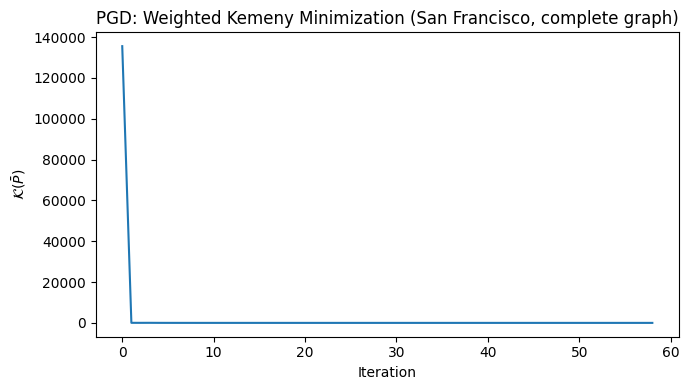

In [3]:
from graph import random_chain
from optimize import _grad_kemeny, make_project_Q_bar, projected_gradient_descent

seed = 42
n_init = 5
alpha_phys = 1e-3
n_iter_phys = 100
tol_phys = 1e-6

rng = np.random.default_rng(seed)
phys_proj = make_project_Q_bar(A_sf, pi_bar_sf)

best_Q_bar = None
kemeny_phys = np.inf
best_history: list[float] = []
for _ in range(n_init):
    Q0 = random_chain(A_sf, seed=int(rng.integers(1 << 31)))
    Q0 = phys_proj(Q0)

    Q_opt, history, n_iters = projected_gradient_descent(
        Q0,
        lambda Q: _grad_kemeny(Q, W_sf),
        phys_proj,
        alpha_phys, n_iter_phys, tol_phys,
    )
    if history and history[-1] < kemeny_phys:
        kemeny_phys = history[-1]
        best_Q_bar = Q_opt
        best_history = history

print(f"Optimized weighted Kemeny constant K(P_bar*): {kemeny_phys:.4f}")
print(f"pi_bar_sf:\n{np.round(pi_bar_sf, 4)}")

plt.figure(figsize=(7, 4))
plt.plot(best_history)
plt.xlabel("Iteration")
plt.ylabel(r"$\mathcal{K}(\bar{P})$")
plt.title("PGD: Weighted Kemeny Minimization (San Francisco, complete graph)")
plt.tight_layout()
plt.show()


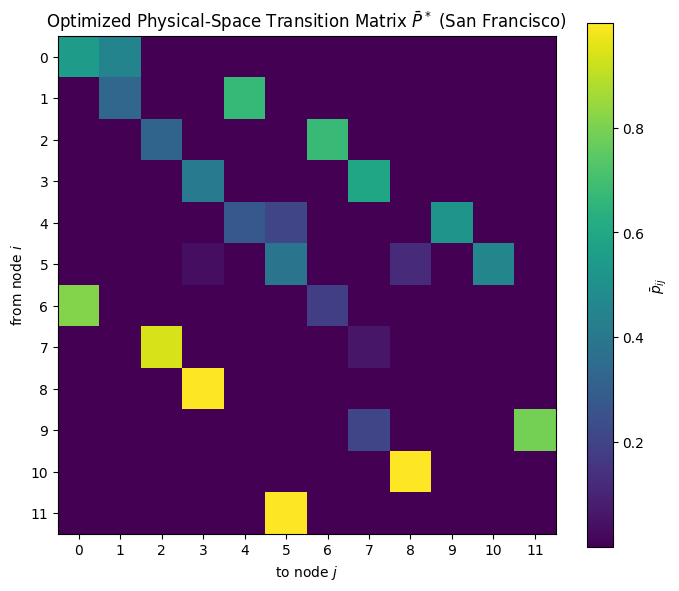

In [4]:
from markov import ergodic_flow_to_transition

P_bar_opt = ergodic_flow_to_transition(best_Q_bar)

plt.figure(figsize=(7, 6))
im = plt.imshow(P_bar_opt, cmap="viridis")
plt.colorbar(im, label=r"$\bar{p}_{ij}$")
plt.xlabel("to node $j$")
plt.ylabel("from node $i$")
plt.xticks(range(len(P_bar_opt)))
plt.yticks(range(len(P_bar_opt)))
plt.title("Optimized Physical-Space Transition Matrix $\\bar{P}^*$ (San Francisco)")
plt.tight_layout()
plt.show()


# Pruned Graph

SF graph pruned (w_max=6): 12 nodes, 106 edges


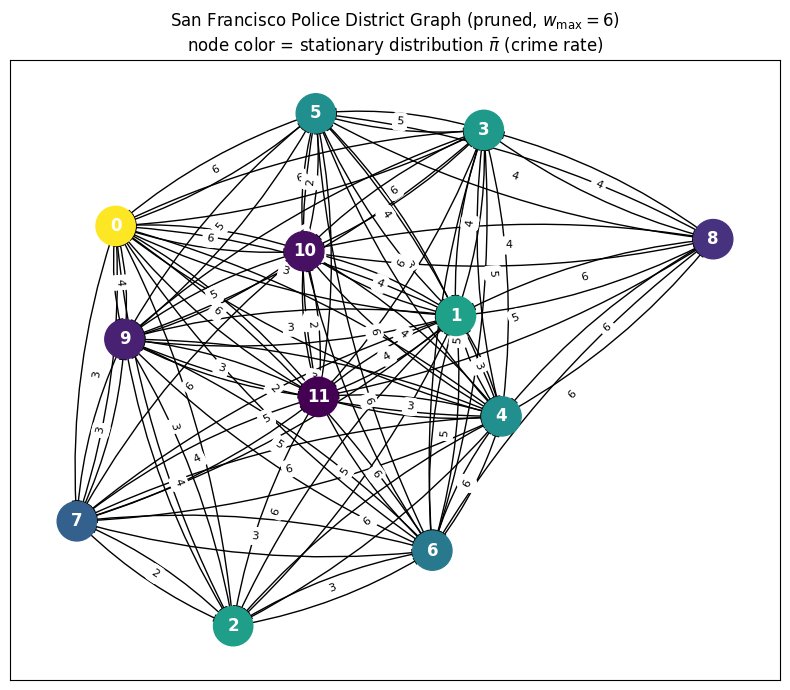

In [5]:
from graph import prune_long_edges

w_max = 6
A_sf_pruned = prune_long_edges(A_sf, W_sf, threshold=w_max)
print(f"SF graph pruned (w_max={w_max}): {A_sf_pruned.shape[0]} nodes, "
      f"{int(A_sf_pruned.sum()) - A_sf_pruned.shape[0]} edges")

G_sf_pruned = nx.from_numpy_array(A_sf_pruned * W_sf, create_using=nx.DiGraph)
G_sf_pruned.remove_edges_from(nx.selfloop_edges(G_sf_pruned))

pos_pruned = nx.spring_layout(G_sf_pruned, seed=42)
edge_labels_pruned = {(i, j): int(w) for i, j, w in G_sf_pruned.edges(data="weight")}

plt.figure(figsize=(8, 7))
nx.draw_networkx_nodes(G_sf_pruned, pos_pruned, node_color=pi_bar_sf, cmap="viridis", node_size=800)
nx.draw_networkx_labels(G_sf_pruned, pos_pruned, font_color="white", font_weight="bold")
nx.draw_networkx_edges(G_sf_pruned, pos_pruned, connectionstyle="arc3,rad=0.1", arrowsize=12)
nx.draw_networkx_edge_labels(G_sf_pruned, pos_pruned, edge_labels=edge_labels_pruned, font_size=8)
plt.title(f"San Francisco Police District Graph (pruned, $w_\\mathrm{{max}}={w_max}$)\n"
          "node color = stationary distribution $\\bar{\\pi}$ (crime rate)")
plt.tight_layout()
plt.show()


/home/yohan/markov_chain_lifting/.venv/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


Optimized weighted Kemeny constant K(P_bar*) on pruned graph: 24.3506
Optimized weighted Kemeny constant K(P_bar*) on complete graph: 23.0563


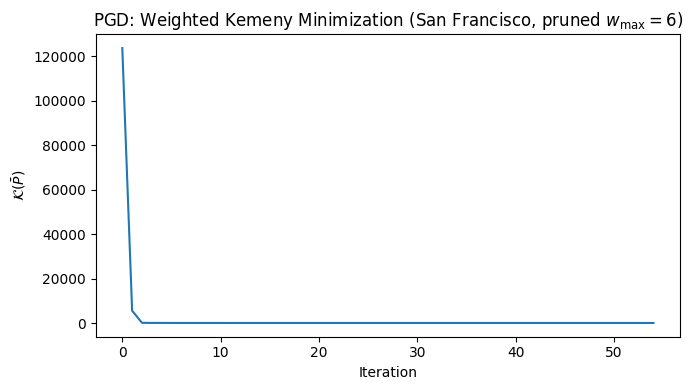

In [6]:
from graph import random_chain
from optimize import _grad_kemeny, make_project_Q_bar, projected_gradient_descent

alpha_phys = 1e-3
n_iter_phys = 100
tol_phys = 1e-6

rng = np.random.default_rng(seed)
phys_proj_pruned = make_project_Q_bar(A_sf_pruned, pi_bar_sf)

best_Q_bar_pruned = None
kemeny_phys_pruned = np.inf
best_history_pruned: list[float] = []
for _ in range(n_init):
    Q0 = random_chain(A_sf_pruned, seed=int(rng.integers(1 << 31)))
    Q0 = phys_proj_pruned(Q0)

    Q_opt, history, n_iters = projected_gradient_descent(
        Q0,
        lambda Q: _grad_kemeny(Q, W_sf),
        phys_proj_pruned,
        alpha_phys, n_iter_phys, tol_phys,
    )
    if history and history[-1] < kemeny_phys_pruned:
        kemeny_phys_pruned = history[-1]
        best_Q_bar_pruned = Q_opt
        best_history_pruned = history

print(f"Optimized weighted Kemeny constant K(P_bar*) on pruned graph: {kemeny_phys_pruned:.4f}")
print(f"Optimized weighted Kemeny constant K(P_bar*) on complete graph: {kemeny_phys:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(best_history_pruned)
plt.xlabel("Iteration")
plt.ylabel(r"$\mathcal{K}(\bar{P})$")
plt.title(f"PGD: Weighted Kemeny Minimization (San Francisco, pruned $w_\\mathrm{{max}}={w_max}$)")
plt.tight_layout()
plt.show()


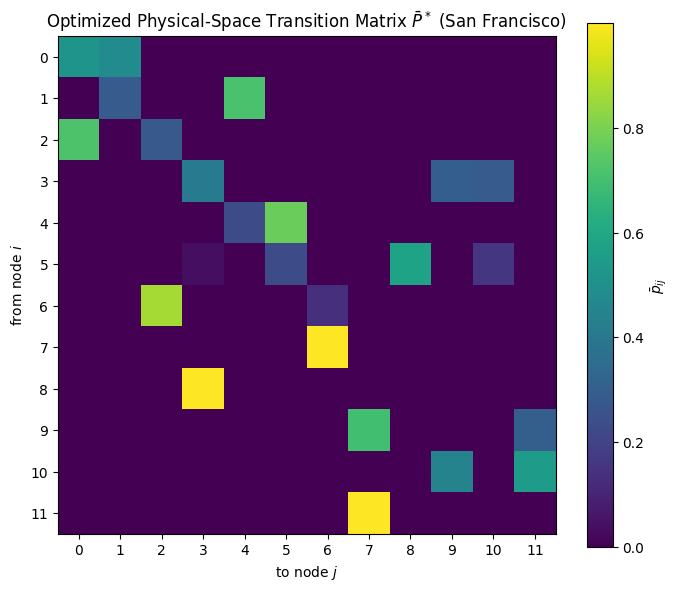

In [7]:
from markov import ergodic_flow_to_transition

P_bar_pruned = ergodic_flow_to_transition(best_Q_bar_pruned)

plt.figure(figsize=(7, 6))
im = plt.imshow(P_bar_pruned, cmap="viridis")
plt.colorbar(im, label=r"$\bar{p}_{ij}$")
plt.xlabel("to node $j$")
plt.ylabel("from node $i$")
plt.xticks(range(len(P_bar_pruned)))
plt.yticks(range(len(P_bar_pruned)))
plt.title("Optimized Physical-Space Transition Matrix $\\bar{P}^*$ (San Francisco)")
plt.tight_layout()
plt.show()


# Lifted Kemeny

In [8]:
from graph import degree_lifting, random_chain
from optimize import _grad_lifted_kemeny, make_project_Q, projected_gradient_descent

eps = 1e-6
alpha_lift = 1e-3
n_iter_lift = 150
tol_lift = 1e-6

# --- Degree lifting of the optimized pruned-graph MC ---
V = degree_lifting(A_sf_pruned)
n, m = V.shape
print(f"Physical nodes m={m}, lifted states n={n}")

A_lift = V @ (best_Q_bar_pruned > eps).astype(int) @ V.T
W_lift = V @ W_sf @ V.T

rng = np.random.default_rng(seed)
lift_proj = make_project_Q(best_Q_bar_pruned, V)

best_Q_lift = None
kemeny_lift = np.inf
best_history_lift: list[float] = []
for _ in range(n_init):
    Q0_lift = random_chain(A_lift, seed=int(rng.integers(1 << 31)))
    Q0_lift = lift_proj(Q0_lift)

    Q_lift_opt, history, n_iters = projected_gradient_descent(
        Q0_lift,
        lambda Q: _grad_lifted_kemeny(Q, V, pi_bar_sf, W_lift),
        lift_proj,
        alpha_lift, n_iter_lift, tol_lift,
    )
    if history and history[-1] < kemeny_lift:
        kemeny_lift = history[-1]
        best_Q_lift = Q_lift_opt
        best_history_lift = history

print(f"Optimized lifted Kemeny constant K^lift(P*):        {kemeny_lift:.4f}")
print(f"Optimized weighted Kemeny constant K(P_bar*) [pruned]: {kemeny_phys_pruned:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(best_history_lift)
plt.xlabel("Iteration")
plt.ylabel(r"$\mathcal{K}^\mathrm{lift}(P)$")
plt.title("PGD: Lifted Kemeny Minimization (San Francisco, pruned graph)")
plt.tight_layout()
plt.show()


Physical nodes m=12, lifted states n=106


/home/yohan/markov_chain_lifting/.venv/lib/python3.10/site-packages/cvxpy/reductions/solvers/solving_chain.py:251: UserWarning: Your problem has too many parameters for efficient DPP compilation. We suggest setting 'ignore_dpp = True'.
  warnings.warn(


RuntimeError: project_Q: QP did not converge (status=user_limit); check that Q_bar is a valid ergodic flow for V